In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fase 4: Visualização dos Dados
Após limparmos os dados e fazermos uma exploração desses dados, o próximo passo consiste em traduzir essa exploração em insights visuais
O objetivo desta seção é comprovar nossas hipóteses iniciais e criar uma narrativa clara sobre o que realmente afeta a produtividade e a saúde mental dos estudantes

In [2]:
df = pd.read_csv("../data/student_productivity_cleaned.csv")
df.head()

,age,academic_level,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,study_hours_total,leisure_screen_time
0,18,0.0,6.52,6.47,81,38,1,0,2.0,10,43.05,31.77,73.65,50.16,11.40,5.24
1,18,0.0,5.97,6.05,111,339,0,0,2.0,3,15.92,37.00,13.70,1.00,6.53,4.20
2,22,0.0,8.39,7.62,68,266,0,1,2.0,8,27.39,34.37,45.15,18.30,3.74,3.42
3,17,0.0,6.31,11.67,113,480,1,1,0.0,3,22.31,77.31,20.92,9.37,10.84,4.47
4,19,0.0,8.01,10.02,121,24,1,0,2.0,8,38.11,39.53,59.23,27.81,11.88,3.35


# Visualização dos dados
- Após limparmos os dados e extrairmos as correlações matemática, o próximo passo 

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

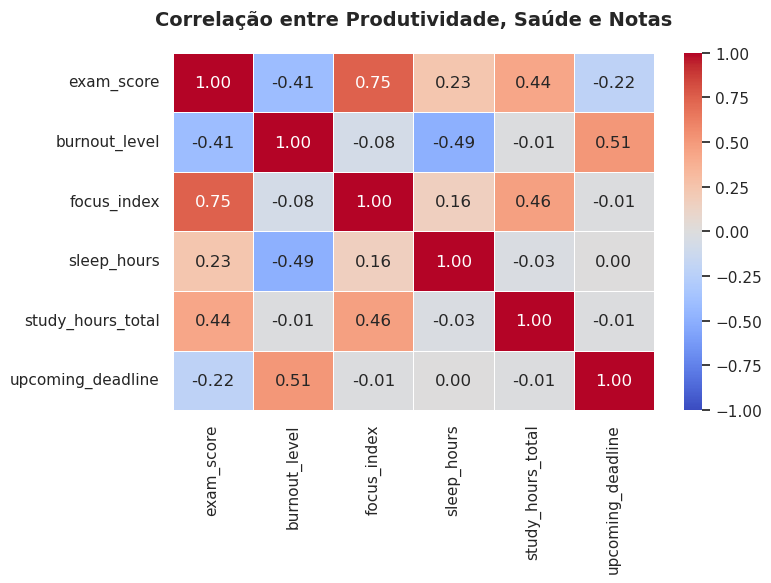

In [13]:
# Selecionamos apenas as colunas que provaram ser mais importantes na Fase 3
colunas_chave = ['exam_score', 'burnout_level', 'focus_index', 'sleep_hours', 'study_hours_total', 'upcoming_deadline']

matriz_corr = df[colunas_chave].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlação entre Produtividade, Saúde e Notas', pad=20, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

## O que o Mapa de Calor nos diz?
-> O Heatmap confirma visualmente as nossas suspeitas da análise exploratória: o sucesso acadêmico (`exam_score`) está fortemente ligado ao foco, enquanto o grande inimigo é o nível de esgotamento mental (`burnout_level`). 


-> Note as cores quentes indicam **relações positivas** enquanto as cores mais frias indicam **relações negativas**

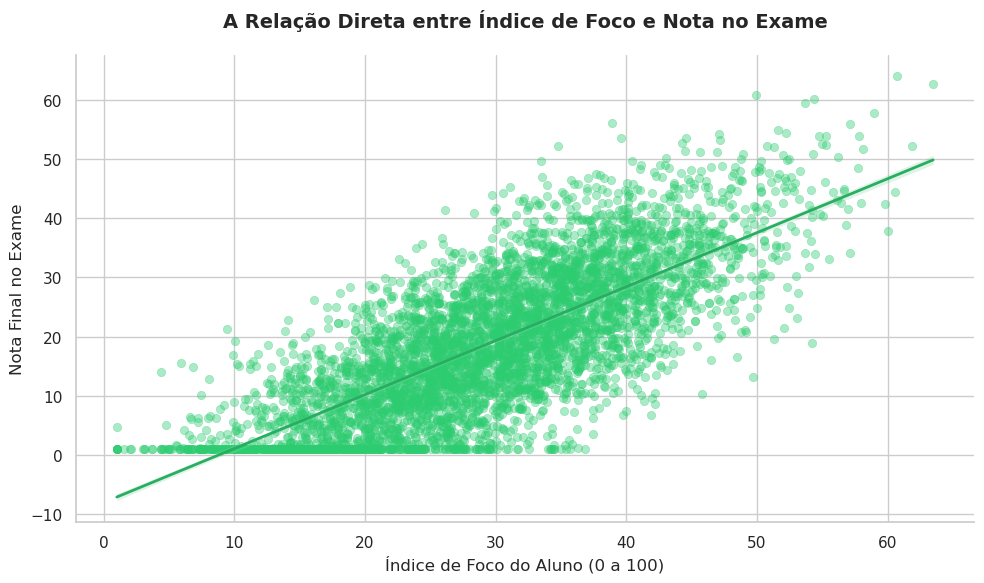

In [6]:
plt.figure(figsize=(10, 6))

# Pontos (scatter) e Linha de Tendência (regplot)
sns.scatterplot(data=df, x='focus_index', y='exam_score', alpha=0.4, color='#2ecc71', edgecolor=None)
sns.regplot(data=df, x='focus_index', y='exam_score', scatter=False, color='#27ae60', line_kws={"linewidth": 2})

plt.title('A Relação Direta entre Índice de Foco e Nota no Exame', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Índice de Foco do Aluno (0 a 100)')
plt.ylabel('Nota Final no Exame')

# Dica: Remover as bordas superior e direita deixa o gráfico mais "clean"
sns.despine()

plt.tight_layout()
plt.show()

## Insight: Qualidade > Quantidade
-> A inclinação ascendente da linha de tendência prova que a capacidade de concentração dos alunos possui grande impacto no exito nos exames


-> A dispersão dos pontos mostra que é praticamente impossível atingir as maiores notas do exame se o índice de foco estiver abaixo de 40. Portanto, estudar focado por menos tempo é a verdadeira métrica de produtividade.

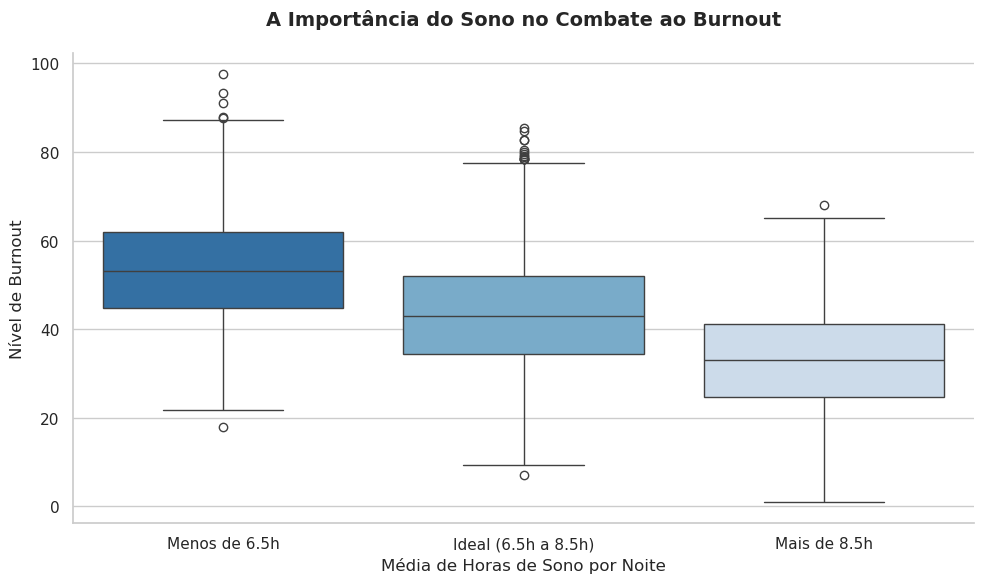

In [8]:
# Para o Boxplot ficar didático, vamos agrupar as horas de sono em categorias (Feature Engineering visual)
df['sleep_category'] = pd.cut(df['sleep_hours'], bins=[0, 6.5, 8.5, 24], labels=['Menos de 6.5h', 'Ideal (6.5h a 8.5h)', 'Mais de 8.5h'])

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='sleep_category', y='burnout_level', hue='sleep_category', palette='Blues_r', legend=False)

plt.title('A Importância do Sono no Combate ao Burnout', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Média de Horas de Sono por Noite')
plt.ylabel('Nível de Burnout')
sns.despine()

plt.tight_layout()
plt.show()

## Insight: Dormir é Produtivo
-> O Boxplot ilustra perfeitamente o sono como um fator de proteção. O boxplot central representa onde a maioria dos alunos se concentra. 


-> Fica claro que alunos que dormem menos de 6.5 horas têm níveis de burnout muito mais altas. Por outro lado, quem dorme a quantidade ideal (6.5h a 8.5h) consegue manter o esgotamento sob controle. O descanso adequado é o melhor antídoto contra o estresse

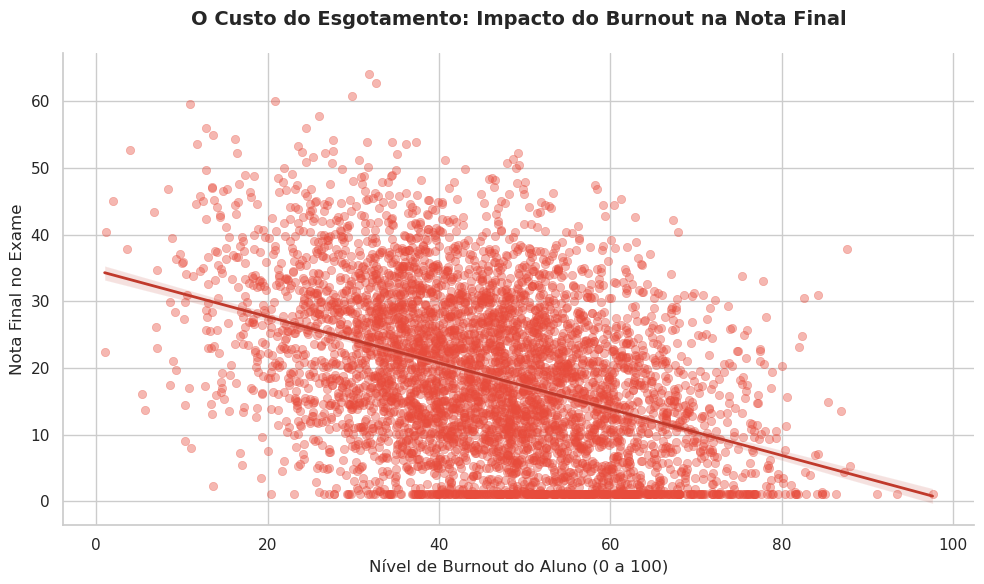

In [ ]:
plt.figure(figsize=(10, 6))

# 1. O Scatterplot (Os pontos)
# Usando a cor vermelha (e74c3c) para remeter a "perigo/esgotamento"
sns.scatterplot(data=df, x='burnout_level', y='exam_score', alpha=0.4, color='#e74c3c', edgecolor=None)

# 2. A Linha de Tendência (Regressão)
# Essa linha vai descer da esquerda para a direita, provando a correlação negativa
sns.regplot(data=df, x='burnout_level', y='exam_score', scatter=False, color='#c0392b', line_kws={"linewidth": 2})

# 3. Estilização
plt.title('O Custo do Esgotamento: Impacto do Burnout na Nota Final', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Nível de Burnout do Aluno (0 a 100)')
plt.ylabel('Nota Final no Exame')

# Limpando as bordas do gráfico (Fica com visual mais "limpo" e profissional)
sns.despine()

plt.tight_layout()
plt.show()

## Conclusão: O Custo Real do Esgotamento
-> Para finalizar com a seção de visualização de nossa análise. A linha de tendência descendente deixa evidente: **o burnout destrói o desempenho acadêmico.**


-> **Visão de Negócio:** > Se o objetivo de uma instituição de ensino é maximizar a taxa de aprovação de seus alunos, a intervenção não deve ser com mais aulas ou mais horas de estudo obrigatório, mas deve ser uma intervenção **psicológica e organizacional**. Redistribuir os prazos de entrega de trabalhos e promover a higiene do sono terá um impacto de ROI (Retorno sobre Investimento) muito maior nas notas finais.